# Census Income con PyTorch: multivariable, regularización, optimización y métricas


Objetivo: construir una red neuronal en PyTorch para clasificar la ocupación de una persona usando todas las variables del censo.

Incluye:
- regularización con `weight_decay`, `Dropout` y `BatchNorm`
- optimización con `SGD`, `Momentum`, `Adam` y scheduler
- métricas multiclase como en el notebook 08: `accuracy`, matriz de confusión, `precision`, `recall`, `F1` y `ROC-AUC`

## 1. Librerías y configuración

Si tu entorno no tiene alguna dependencia, descomenta la línea de instalación.

In [83]:
# %pip install numpy pandas scikit-learn matplotlib torch

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cpu


In [84]:
df = pd.read_csv('adult.csv').copy()
df.head()


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


## 2. Carga y preprocesamiento

La red no trabaja directamente con categorías de texto, así que transformamos las variables numéricas y categóricas por separado.

En este modelo el target es multiclase: `occupation`. Por eso usamos `LabelEncoder` y métricas promediadas (`macro` y `weighted`).

In [85]:
df.columns = [c.strip() for c in df.columns]
for col in df.select_dtypes(include=['object', 'string']).columns:
    df[col] = df[col].astype(str).str.strip()

df = df.replace('?', np.nan)
target_col = 'occupation'

df = df.dropna(subset=[target_col]).copy()

X = df.drop(columns=[target_col])
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df[target_col].astype(str))
class_names = label_encoder.classes_
num_classes = len(class_names)

print('Shape X:', X.shape)
print('Número de clases:', num_classes)
print('Clases:', list(class_names))

Shape X: (30718, 14)
Número de clases: 14
Clases: ['Adm-clerical', 'Armed-Forces', 'Craft-repair', 'Exec-managerial', 'Farming-fishing', 'Handlers-cleaners', 'Machine-op-inspct', 'Other-service', 'Priv-house-serv', 'Prof-specialty', 'Protective-serv', 'Sales', 'Tech-support', 'Transport-moving']


In [86]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=SEED, stratify=y_temp
)

X_subset, y_subset = X_train[:5000], y_train[:5000]

num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object', 'string']).columns.tolist()

num_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipe, num_cols),
        ('cat', cat_pipe, cat_cols),
    ]
)


In [87]:
X_train_t = preprocessor.fit_transform(X_train)
X_val_t = preprocessor.transform(X_val)
X_test_t = preprocessor.transform(X_test)

if hasattr(X_train_t, 'toarray'):
    X_train_t = X_train_t.toarray()
if hasattr(X_val_t, 'toarray'):
    X_val_t = X_val_t.toarray()
if hasattr(X_test_t, 'toarray'):
    X_test_t = X_test_t.toarray()

X_train_t = X_train_t.astype(np.float32)
X_val_t = X_val_t.astype(np.float32)
X_test_t = X_test_t.astype(np.float32)
y_train_np = y_train.astype(np.int64)
y_val_np = y_val.astype(np.int64)
y_test_np = y_test.astype(np.int64)

In [88]:
class CensusDataset(torch.utils.data.Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X).float()
        self.y = torch.from_numpy(y).long()

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


# Estructura tipo dataset + dataloader
# Creamos un objeto Dataset por partición y luego un DataLoader por split
datasets = {
    'train': CensusDataset(X_train_t, y_train_np),
    'val': CensusDataset(X_val_t, y_val_np),
    'test': CensusDataset(X_test_t, y_test_np),
}

dataloaders = {
    'train': DataLoader(datasets['train'], batch_size=256, shuffle=True),
    'val': DataLoader(datasets['val'], batch_size=512, shuffle=False),
    'test': DataLoader(datasets['test'], batch_size=512, shuffle=False),
}

dataloader = dataloaders

train_ds = datasets['train']
val_ds = datasets['val']
test_ds = datasets['test']

train_loader = dataloaders['train']
val_loader = dataloaders['val']
test_loader = dataloaders['test']

input_dim = X_train_t.shape[1]
class_counts = np.bincount(y_train_np, minlength=num_classes)

In [89]:
print('X_train:', X_train.shape, 'X_val:', X_val.shape, 'X_test:', X_test.shape, 'X_subset:', X_subset.shape)
print('input_dim:', input_dim)

X_train: (24574, 14) X_val: (3072, 14) X_test: (3072, 14) X_subset: (5000, 14)
input_dim: 91


## 3. Regularización

La regularización reduce el sobreajuste. En este modelo la aplicamos de tres formas:
- `weight_decay`: penaliza pesos grandes y hace la red más estable
- `Dropout`: apaga neuronas durante el entrenamiento para evitar dependencia excesiva
- `BatchNorm`: normaliza activaciones internas y acelera el entrenamiento

Eso suele bajar un poco la precisión de entrenamiento, pero mejora la capacidad de generalización.

In [90]:
class CensusBinaryMLP(nn.Module):
    def __init__(self, in_features, n_classes, hidden1=256, hidden2=128, dropout=0.0, batchnorm=False):
        super().__init__()
        layers = [nn.Linear(in_features, hidden1)]
        if batchnorm:
            layers.append(nn.BatchNorm1d(hidden1))
        layers.append(nn.ReLU())
        if dropout > 0:
            layers.append(nn.Dropout(dropout))
        layers.append(nn.Linear(hidden1, hidden2))
        if batchnorm:
            layers.append(nn.BatchNorm1d(hidden2))
        layers.append(nn.ReLU())
        if dropout > 0:
            layers.append(nn.Dropout(dropout))
        layers.append(nn.Linear(hidden2, n_classes))
        self.net = nn.Sequential(*layers)

        for layer in self.net:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_uniform_(layer.weight)
                nn.init.zeros_(layer.bias)

    def forward(self, x):
        return self.net(x)

## 4. Optimización

La optimización es la forma en que la red ajusta sus pesos para minimizar el error.

Aquí compararemos dos enfoques:
- `AdamW` sin regularización extra como referencia
- `AdamW` con `Dropout`, `BatchNorm` y `weight_decay` como versión regularizada

Con este target tan desbalanceado, una pérdida no ponderada suele dar mejor accuracy global que forzar demasiado las clases minoritarias.

In [91]:
def softmax(x):
    return torch.exp(x) / torch.exp(x).sum(dim=-1, keepdim=True)


def build_model(hidden1=256, hidden2=128, dropout=0.0, batchnorm=True):
    return CensusBinaryMLP(
        input_dim,
        num_classes,
        hidden1=hidden1,
        hidden2=hidden2,
        dropout=dropout,
        batchnorm=batchnorm,
    ).to(device)


def fit(model, dataloader, optimizer, epochs=100, log_each=10, early_stopping=0):
    criterion = nn.CrossEntropyLoss()
    train_loss_hist, train_acc_hist = [], []
    val_loss_hist, val_acc_hist = [], []
    best_val_acc = 0.0
    steps_without_improve = 0
    checkpoint_path = 'ckpt.pt'

    for epoch in range(1, epochs + 1):
        model.train()
        batch_losses, batch_accs = [], []

        for x_b, y_b in dataloader['train']:
            x_b = x_b.to(device)
            y_b = y_b.to(device)

            y_pred = model(x_b)
            loss = criterion(y_pred, y_b)
            batch_losses.append(loss.item())

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            y_probas = torch.argmax(softmax(y_pred), dim=1)
            batch_accs.append(accuracy_score(y_b.detach().cpu().numpy(), y_probas.detach().cpu().numpy()))

        train_loss = float(np.mean(batch_losses))
        train_acc = float(np.mean(batch_accs))
        train_loss_hist.append(train_loss)
        train_acc_hist.append(train_acc)

        model.eval()
        val_batch_losses, val_batch_accs = [], []
        with torch.no_grad():
            for x_b, y_b in dataloader['val']:
                x_b = x_b.to(device)
                y_b = y_b.to(device)

                y_pred = model(x_b)
                loss = criterion(y_pred, y_b)
                val_batch_losses.append(loss.item())

                y_probas = torch.argmax(softmax(y_pred), dim=1)
                val_batch_accs.append(accuracy_score(y_b.detach().cpu().numpy(), y_probas.detach().cpu().numpy()))

        val_loss = float(np.mean(val_batch_losses))
        val_acc = float(np.mean(val_batch_accs))
        val_loss_hist.append(val_loss)
        val_acc_hist.append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), checkpoint_path)
            steps_without_improve = 0
            print(f"Mejor modelo guardado con acc {best_val_acc:.5f} en epoch {epoch}")
        else:
            steps_without_improve += 1

        if early_stopping and steps_without_improve > early_stopping:
            print(f"Entrenamiento detenido en epoch {epoch} por no mejorar en {early_stopping} epochs seguidas")
            break

        if not epoch % log_each:
            print(
                f"Epoch {epoch}/{epochs} loss {train_loss:.5f} acc {train_acc:.5f} "
                f"val_loss {val_loss:.5f} val_acc {val_acc:.5f}"
            )

    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    return {
        'epoch': list(range(1, len(train_loss_hist) + 1)),
        'loss': train_loss_hist,
        'acc': train_acc_hist,
        'val_loss': val_loss_hist,
        'val_acc': val_acc_hist,
    }

## 5. Experimento base y experimento regularizado

El experimento base usa un optimizador simple. El experimento regularizado usa técnicas combinadas de 05 y 06: Dropout, BatchNorm, weight decay, Adam, scheduler y early stopping.

Descenso de Gradiente Estocástico (SGD)

In [92]:
model = build_model()
optimizer = torch.optim.SGD(model.parameters(), lr=0.001)
hist_sgd = fit(model, dataloader, optimizer, epochs=100, log_each=1, early_stopping=5)

Mejor modelo guardado con acc 0.10938 en epoch 1
Epoch 1/100 loss 2.81057 acc 0.07728 val_loss 2.68616 val_acc 0.10938
Mejor modelo guardado con acc 0.15723 en epoch 2
Epoch 2/100 loss 2.62425 acc 0.12786 val_loss 2.52938 val_acc 0.15723
Mejor modelo guardado con acc 0.19466 en epoch 3
Epoch 3/100 loss 2.49487 acc 0.17462 val_loss 2.42696 val_acc 0.19466
Mejor modelo guardado con acc 0.22526 en epoch 4
Epoch 4/100 loss 2.40234 acc 0.21092 val_loss 2.34865 val_acc 0.22526
Mejor modelo guardado con acc 0.25033 en epoch 5
Epoch 5/100 loss 2.33366 acc 0.23525 val_loss 2.29056 val_acc 0.25033
Mejor modelo guardado con acc 0.26660 en epoch 6
Epoch 6/100 loss 2.28023 acc 0.25572 val_loss 2.24689 val_acc 0.26660
Mejor modelo guardado con acc 0.27734 en epoch 7
Epoch 7/100 loss 2.24041 acc 0.26723 val_loss 2.21045 val_acc 0.27734
Mejor modelo guardado con acc 0.28288 en epoch 8
Epoch 8/100 loss 2.20788 acc 0.27326 val_loss 2.18021 val_acc 0.28288
Mejor modelo guardado con acc 0.28711 en epoch 9

Momentum

In [93]:
model = build_model()
optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
hist_momentum = fit(model, dataloader, optimizer, epochs=100, log_each=1, early_stopping=5)

Mejor modelo guardado con acc 0.27962 en epoch 1
Epoch 1/100 loss 2.54724 acc 0.18357 val_loss 2.15066 val_acc 0.27962
Mejor modelo guardado con acc 0.31055 en epoch 2
Epoch 2/100 loss 2.08495 acc 0.29861 val_loss 2.03551 val_acc 0.31055
Mejor modelo guardado con acc 0.32194 en epoch 3
Epoch 3/100 loss 2.00520 acc 0.31688 val_loss 1.98961 val_acc 0.32194
Mejor modelo guardado con acc 0.33268 en epoch 4
Epoch 4/100 loss 1.96490 acc 0.32555 val_loss 1.96249 val_acc 0.33268
Epoch 5/100 loss 1.93663 acc 0.33434 val_loss 1.94269 val_acc 0.33171
Mejor modelo guardado con acc 0.33529 en epoch 6
Epoch 6/100 loss 1.91750 acc 0.33894 val_loss 1.92931 val_acc 0.33529
Mejor modelo guardado con acc 0.33854 en epoch 7
Epoch 7/100 loss 1.90150 acc 0.34256 val_loss 1.91647 val_acc 0.33854
Epoch 8/100 loss 1.88917 acc 0.34691 val_loss 1.90758 val_acc 0.33757
Mejor modelo guardado con acc 0.34473 en epoch 9
Epoch 9/100 loss 1.87785 acc 0.34838 val_loss 1.90002 val_acc 0.34473
Epoch 10/100 loss 1.87001 a

Adam

In [94]:
model = build_model()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
hist_adam = fit(model, dataloader, optimizer, epochs=100, log_each=1, early_stopping=5)

Mejor modelo guardado con acc 0.35221 en epoch 1
Epoch 1/100 loss 2.02888 acc 0.30801 val_loss 1.88405 val_acc 0.35221
Epoch 2/100 loss 1.84889 acc 0.35326 val_loss 1.86383 val_acc 0.34180
Mejor modelo guardado con acc 0.35384 en epoch 3
Epoch 3/100 loss 1.81676 acc 0.35969 val_loss 1.85599 val_acc 0.35384
Epoch 4/100 loss 1.79063 acc 0.37153 val_loss 1.85818 val_acc 0.34766
Epoch 5/100 loss 1.77062 acc 0.37519 val_loss 1.85245 val_acc 0.34766
Epoch 6/100 loss 1.75699 acc 0.38019 val_loss 1.86247 val_acc 0.35221
Epoch 7/100 loss 1.74169 acc 0.38622 val_loss 1.87426 val_acc 0.34798
Epoch 8/100 loss 1.72836 acc 0.39131 val_loss 1.87600 val_acc 0.34115
Entrenamiento detenido en epoch 9 por no mejorar en 5 epochs seguidas


RMSProp

In [95]:
model = build_model()
optimizer = torch.optim.RMSprop(model.parameters(), lr=0.001)
hist_rms = fit(model, dataloader, optimizer)    

Mejor modelo guardado con acc 0.34635 en epoch 1
Mejor modelo guardado con acc 0.35254 en epoch 2
Mejor modelo guardado con acc 0.36035 en epoch 4
Epoch 10/100 loss 1.69160 acc 0.40160 val_loss 1.88235 val_acc 0.34603
Epoch 20/100 loss 1.57602 acc 0.43724 val_loss 1.96168 val_acc 0.33040
Epoch 30/100 loss 1.48845 acc 0.46899 val_loss 2.05231 val_acc 0.31934
Epoch 40/100 loss 1.41906 acc 0.49422 val_loss 2.11906 val_acc 0.31413
Epoch 50/100 loss 1.36681 acc 0.51274 val_loss 2.20963 val_acc 0.30599
Epoch 60/100 loss 1.32458 acc 0.52373 val_loss 2.24227 val_acc 0.30990
Epoch 70/100 loss 1.28378 acc 0.53764 val_loss 2.34952 val_acc 0.30534
Epoch 80/100 loss 1.25315 acc 0.54728 val_loss 2.41087 val_acc 0.30339
Epoch 90/100 loss 1.21988 acc 0.55661 val_loss 2.45626 val_acc 0.29395
Epoch 100/100 loss 1.19768 acc 0.57008 val_loss 2.50937 val_acc 0.29069


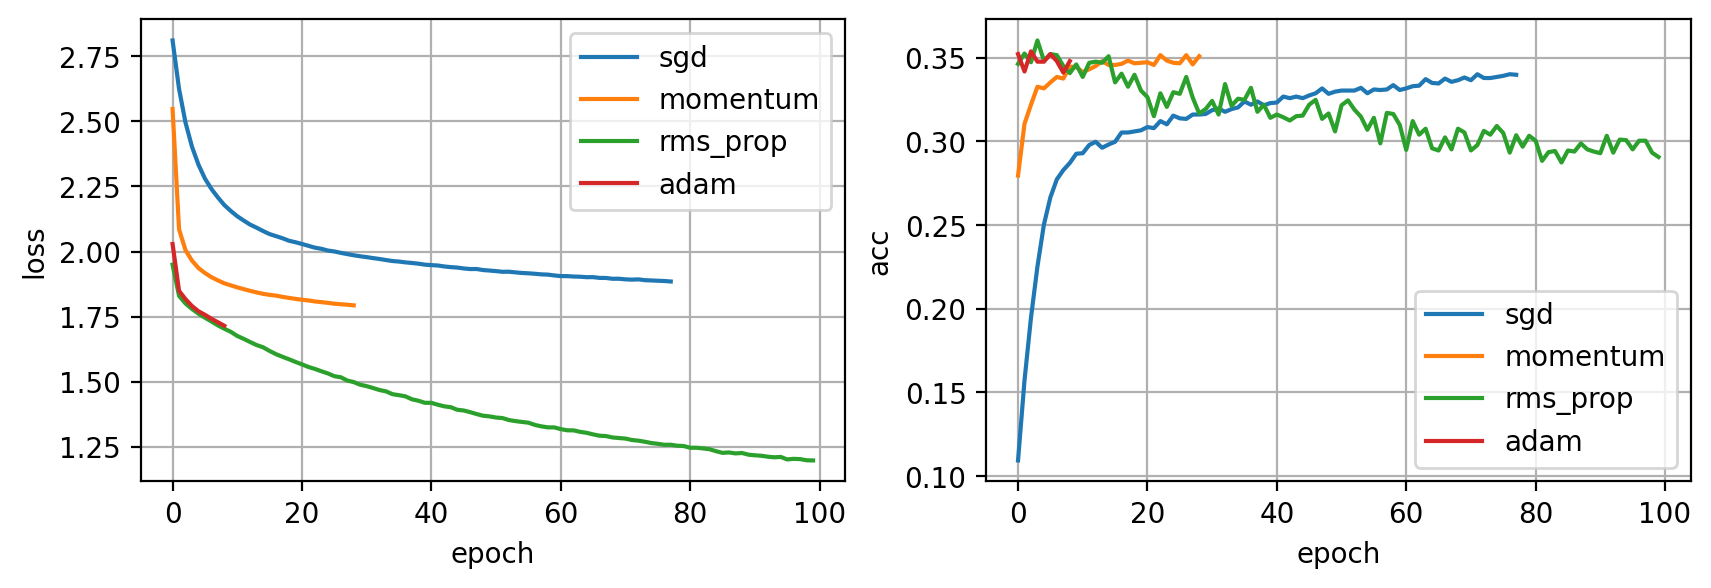

In [96]:
import matplotlib.pyplot as plt

fig = plt.figure(dpi=200, figsize=(10,3))
ax = plt.subplot(121)
ax.plot(hist_sgd['loss'], label="sgd")
ax.plot(hist_momentum['loss'], label="momentum")
ax.plot(hist_rms['loss'], label="rms_prop")
ax.plot(hist_adam['loss'], label="adam")
ax.legend()
ax.grid(True)
ax.set_xlabel('epoch')
ax.set_ylabel('loss')
ax = plt.subplot(122)
ax.plot(hist_sgd['val_acc'], label="sgd")
ax.plot(hist_momentum['val_acc'], label="momentum")
ax.plot(hist_rms['val_acc'], label="rms_prop")
ax.plot(hist_adam['val_acc'], label="adam")
ax.legend()
ax.grid(True)
ax.set_ylabel('acc')
ax.set_xlabel('epoch')
plt.show()

Normalización
Normalizar los datos es clave para entrenar redes neuronales más rápido y de forma estable. Ya vimos que dividir las imágenes por 255 ayuda a que los valores estén entre 0 y 1. Otra opción común es ajustar las imágenes para que tengan media 0 y desviación estándar 1, usando el promedio y la desviación estándar del propio dataset.

In [97]:
prec_reg_macro = metric_precision(y_true_r, y_pred_r, average='macro')
rec_reg_macro = metric_recall(y_true_r, y_pred_r, average='macro')
prec_base_macro = metric_precision(y_true_b, y_pred_b, average='macro')
rec_base_macro = metric_recall(y_true_b, y_pred_b, average='macro')
prec_reg_weighted = metric_precision(y_true_r, y_pred_r, average='weighted')
rec_reg_weighted = metric_recall(y_true_r, y_pred_r, average='weighted')
prec_base_weighted = metric_precision(y_true_b, y_pred_b, average='weighted')
rec_base_weighted = metric_recall(y_true_b, y_pred_b, average='weighted')

print(f'Precision baseline macro: {prec_base_macro:.4f} | Recall baseline macro: {rec_base_macro:.4f}')
print(f'Precision regularizado macro: {prec_reg_macro:.4f} | Recall regularizado macro: {rec_reg_macro:.4f}')
print(f'Precision baseline weighted: {prec_base_weighted:.4f} | Recall baseline weighted: {rec_base_weighted:.4f}')
print(f'Precision regularizado weighted: {prec_reg_weighted:.4f} | Recall regularizado weighted: {rec_reg_weighted:.4f}')

NameError: name 'y_true_r' is not defined

### F1-Score

Resume precision y recall en un solo número. Es útil cuando quieres balance entre falsos positivos y falsos negativos. En multiclase suele reportarse con promedio `macro` y `weighted`.

In [ ]:
f1_base_macro = metric_f1(y_true_b, y_pred_b, average='macro')
f1_reg_macro = metric_f1(y_true_r, y_pred_r, average='macro')
f1_base_weighted = metric_f1(y_true_b, y_pred_b, average='weighted')
f1_reg_weighted = metric_f1(y_true_r, y_pred_r, average='weighted')

print(f'F1 baseline macro: {f1_base_macro:.4f}')
print(f'F1 regularizado macro: {f1_reg_macro:.4f}')
print(f'F1 baseline weighted: {f1_base_weighted:.4f}')
print(f'F1 regularizado weighted: {f1_reg_weighted:.4f}')

F1 baseline macro: 0.0873
F1 regularizado macro: 0.2327
F1 baseline weighted: 0.1149
F1 regularizado weighted: 0.2698


### ROC-AUC

Mide la capacidad del modelo para separar las clases sin depender de un threshold fijo. Valores más cercanos a 1 indican mejor separación entre clases.

In [ ]:
auc_base = metric_roc_auc(y_true_b, y_proba_b)
auc_reg = metric_roc_auc(y_true_r, y_proba_r)

print(f'ROC-AUC baseline OVR macro: {auc_base:.4f}')
print(f'ROC-AUC regularizado OVR macro: {auc_reg:.4f}')

print('')
print('Reporte de clasificación - baseline')
print(classification_report(y_true_b, y_pred_b, target_names=class_names, digits=4))
print('Reporte de clasificación - regularizado')
print(classification_report(y_true_r, y_pred_r, target_names=class_names, digits=4))

ROC-AUC baseline OVR macro: 0.7018
ROC-AUC regularizado OVR macro: 0.8020

Reporte de clasificación - baseline
                   precision    recall  f1-score   support

     Adm-clerical     0.1692    0.0146    0.0269       754
     Armed-Forces     0.0000    0.0000    0.0000         2
     Craft-repair     0.0000    0.0000    0.0000       820
  Exec-managerial     0.2857    0.0074    0.0144       813
  Farming-fishing     0.1242    0.2010    0.1536       199
Handlers-cleaners     0.0906    0.1679    0.1176       274
Machine-op-inspct     0.0707    0.0175    0.0281       400
    Other-service     0.1394    0.2458    0.1779       659
  Priv-house-serv     0.0127    0.8000    0.0249        30
   Prof-specialty     0.3938    0.6944    0.5026       828
  Protective-serv     0.0000    0.0000    0.0000       130
            Sales     0.1043    0.0233    0.0381       730
     Tech-support     0.0462    0.0484    0.0472       186
 Transport-moving     0.1028    0.0815    0.0909       319

  

c:\Users\jorge\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\jorge\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\jorge\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

## 7. Comparación final

Esta tabla resume el desempeño alcanzado por ambos enfoques. El modelo regularizado suele generalizar mejor, aunque no siempre consigue la mayor accuracy.

In [ ]:
summary = pd.DataFrame({
    'modelo': ['baseline', 'regularizado'],
    'accuracy': [acc_base, acc_reg],
    'precision_macro': [prec_base_macro, prec_reg_macro],
    'recall_macro': [rec_base_macro, rec_reg_macro],
    'f1_macro': [f1_base_macro, f1_reg_macro],
    'f1_weighted': [f1_base_weighted, f1_reg_weighted],
    'roc_auc_ovr_macro': [auc_base, auc_reg],
})
summary.round(4)

,modelo,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted,roc_auc_ovr_macro
0,baseline,0.1502,0.1100,0.1644,0.0873,0.1149,0.7018
1,regularizado,0.2788,0.2434,0.3500,0.2327,0.2698,0.8020


## 8. Interpretación

- `Regularización` evita que la red aprenda patrones demasiado específicos del entrenamiento y ayuda a generalizar.
- `Optimización` decide cómo se actualizan los pesos; `Adam` y `Momentum` suelen converger mejor que `SGD` simple.
- `Accuracy` indica aciertos totales, pero no basta cuando las clases están desbalanceadas.
- `Precision` y `Recall` en versión `macro` y `weighted` permiten ver el rendimiento por clase y el rendimiento global.
- `F1` resume precision y recall en una sola medida.
- `ROC-AUC OVR` mide la calidad de separación entre clases en un escenario multiclase.

Cuando ejecutes el notebook, la tabla final te dará los niveles de precisión alcanzados por el modelo baseline y el regularizado para la predicción de `occupation`.